In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd

from pathlib import Path

from src import utils

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=1.25)

from src.data.datasets import EulfsDs

%load_ext autoreload
%autoreload 2

In [2]:
config_paths = "paths_config.yml"
config_data = "data_config.yml"

In [3]:
eulfs = EulfsDs(fn_config_path=config_paths, fn_config_data=config_data)

In [4]:
df_all = eulfs.read()

T:\Documents\Projects\04_jrc_green-skills-regional\03_data-analysis\re4gt\src\data\datasets.py:1156: DtypeWarning: Columns (6,10) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(fpath, index_col=0)


In [7]:
df_all.columns

Index(['SEX', 'WSTATOR', 'NACE1D', 'ISCO3D', 'COUNTRYW', 'REGIONW', 'FTPT',
       'REFYEAR', 'COUNTRY', 'REGION', 'DEGURBA', 'HHTYPE', 'COEFF', 'AGE',
       'ILOSTAT', 'EDUC4WN', 'HATLEV1D', 'MAINSTAT', 'INCDECIL', 'NUTS_ID',
       'isco_level_3', 'share_green_gtp_mean', 'share_green_gtp_std',
       'share_green_gtp_median', 'share_green_gtp_iqr', 'n_occ_esco_sum',
       'share_green_esco_mean', 'share_green_esco_std',
       'share_green_esco_median', 'share_green_esco_iqr',
       'share_brown_esco_mean', 'share_brown_esco_std',
       'share_brown_esco_median', 'share_brown_esco_iqr',
       'share_neutral_esco_mean', 'share_neutral_esco_std',
       'share_neutral_esco_median', 'share_neutral_esco_iqr', 'NACE1D_label',
       'COEFF_share_green_gtp_mean', 'COEFF_share_green_gtp_std',
       'COEFF_share_green_gtp_median', 'COEFF_share_green_gtp_iqr',
       'COEFF_share_green_esco_mean', 'COEFF_share_green_esco_std',
       'COEFF_share_green_esco_median', 'COEFF_share_green_e

In [18]:
gdf_sub = pd.merge(
    eulfs.gdf_nuts,
    df_all.groupby("NUTS_ID")[["COEFF", "COEFF_share_green_esco_mean",
                               "COEFF_share_brown_esco_mean"]].sum()
        .reset_index(),
    on="NUTS_ID",
    how="left"
)

In [19]:
gdf_sub["relative_COEFF_share_green_esco_mean"] = gdf_sub["COEFF_share_green_esco_mean"] / gdf_sub["COEFF"]
gdf_sub["relative_COEFF_share_brown_esco_mean"] = \
    gdf_sub["COEFF_share_brown_esco_mean"] / gdf_sub["COEFF"]


Map of Europe

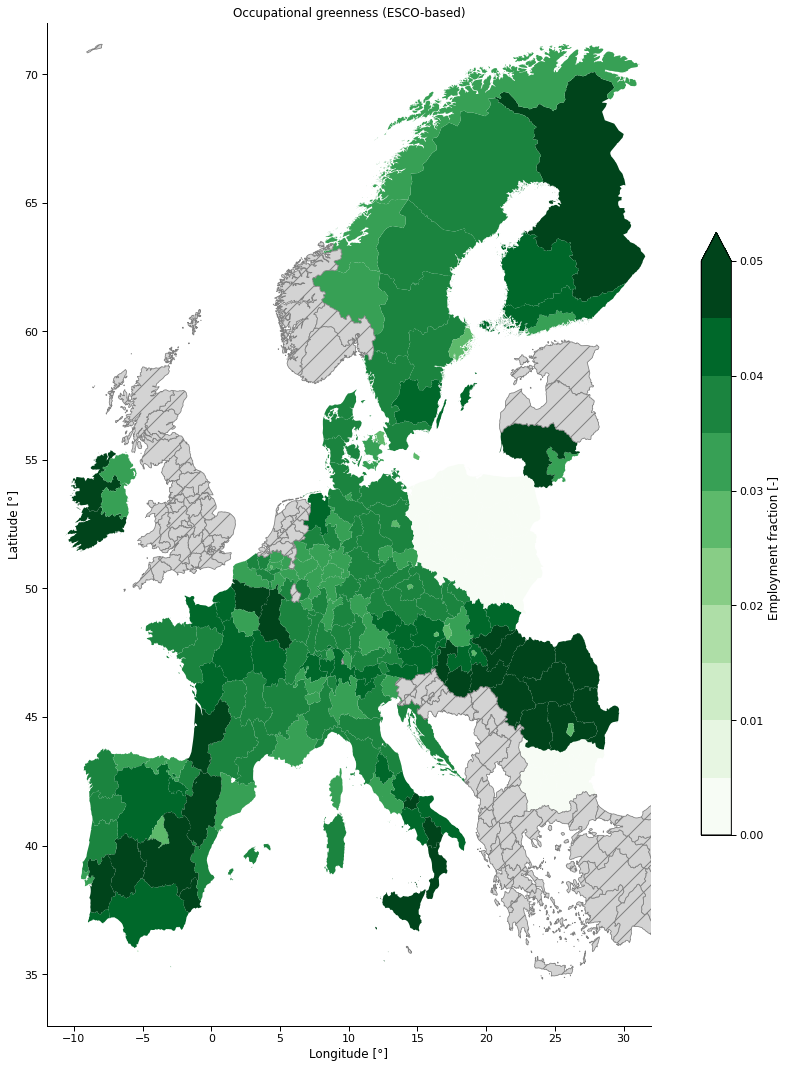

In [35]:
ax = gdf_sub.plot(
    column="relative_COEFF_share_green_esco_mean",
    figsize=(15, 15),
    legend=True,
    cmap=plt.get_cmap("Greens", 10),
    vmax=0.05,
    # scheme="EqualInterval",
    # k=8,
    missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
    legend_kwds={"label": "Employment fraction [-]", "fraction": 0.03, "extend": "max"}
)

ax.set_title("Occupational greenness (ESCO-based)")
ax.set_xlim(-12, 32)
ax.set_ylim(33, 72)

ax.set_xlabel("Longitude [°]")
ax.set_ylabel("Latitude [°]")

plt.tight_layout()
sns.despine()

plt.savefig(
    os.path.join(eulfs.figure_dir, "preliminary", "occupational_greenness_ESCO_based.png"),
    dpi=300,
    bbox_inches="tight"
)

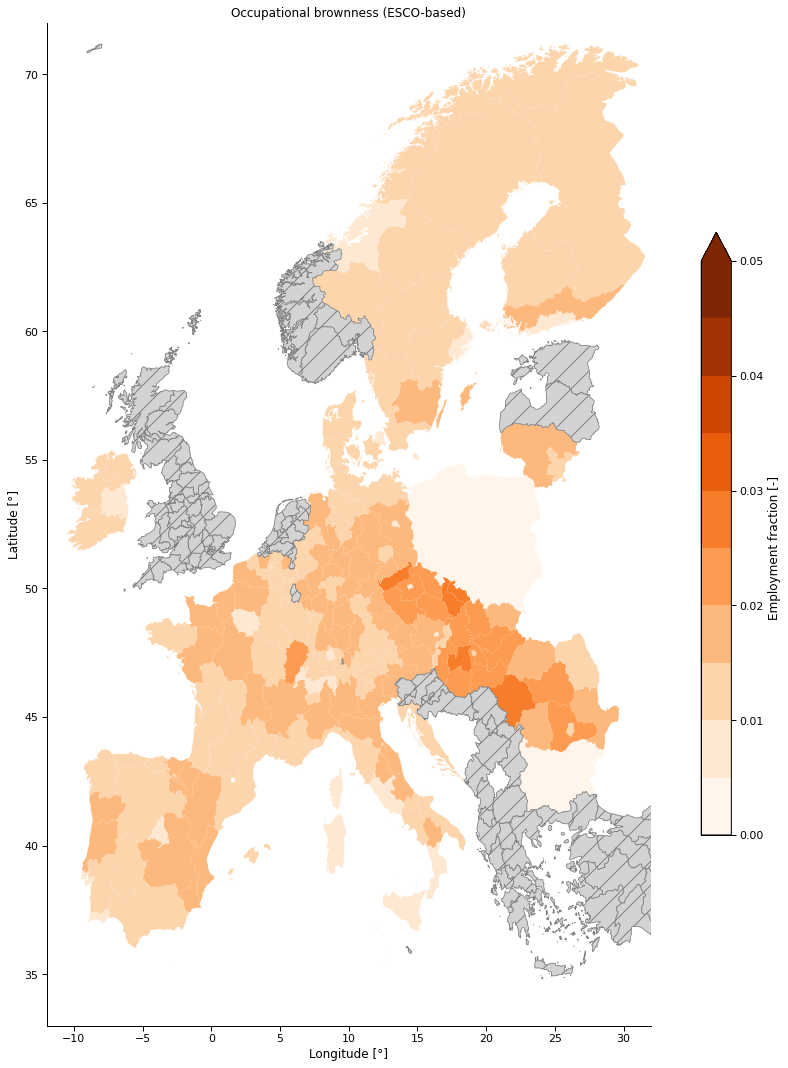

In [34]:
ax = gdf_sub.plot(
    column="relative_COEFF_share_brown_esco_mean",
    figsize=(15, 15),
    legend=True,
    cmap=plt.get_cmap("Oranges", 10),
    vmax=0.05,
    # scheme="EqualInterval",
    # k=8,
    missing_kwds={"facecolor": "lightgrey", "hatch": "/", "edgecolor": "grey"},
    legend_kwds={"label": "Employment fraction [-]", "fraction": 0.03, "extend": "max"}
)

ax.set_title("Occupational brownness (ESCO-based)")
ax.set_xlim(-12, 32)
ax.set_ylim(33, 72)

ax.set_xlabel("Longitude [°]")
ax.set_ylabel("Latitude [°]")

plt.tight_layout()
sns.despine()

plt.savefig(
    os.path.join(eulfs.figure_dir, "preliminary", "occupational_brownness_ESCO_based.png"),
    dpi=300,
    bbox_inches="tight"
)